In [3]:
print(sys.executable)

g:\Mi unidad\Tesis v1\mt\Scripts\python.exe


## ENTRENAMIENTO DE MODELOS EN BASE A NUESTRO DATASET PREPROCESADO ANTERIORMENTE
#### Dentro de este jupyter se presenta todo el proceso de entrenamiento de un nuevo modelo en base a los datos que recopilamos y preprocesamos en el notebook anterior. Este notebook presenta todo el proceso de entrenamiento, evaluación y ajuste fino para la clasificación de los paradigmas dentro de una señal EEG
##### Este notebook es una muestra simple de cómo poder usar la librería `Backend_DL`para un pipeline completo de formación de modelos de predicción de paradigmas EEG, con ayuda de ***EEGNET*** y *TensorFLOW* 

##### Los objetivos principales de esta librería son:

- Creación de un objeto para la preselección de los datos 
- Preselección de las clases para entrenar
- Selección de los canales a utilizar
- Creación de npz a formato compatible con entrenamiento de Keras 
- Separación de clases y undersampleo y balance de las mismas 
- Split de los datos de entrenamiento con estratificación en sujetos, sesiones o triales compatibles con el formato [MOABB](https://moabb.neurotechx.com/docs/index.html)
- Normalización de los datos para keras
- Entrenamiento general del modelo con definición de hiperparámetros 
- Aplicación de ajuste fino 
- Evaluación y métricas de los modelos

### 1) Establecer área de trabajo (Pueden ignorar esta primera celda y sólo importar la librería)

In [1]:
import os
import sys
import numpy as np

project_path = 'G:\\Mi unidad\\Tesis v1'
print(f"Ruta de trabajo actual: {project_path}")



os.chdir(project_path) #change directory B)
sys.path.append(project_path)


#Elegimos la ruta donde trabajaremos con colab
BASE_FOLDER = os.path.join(project_path, 'Movement_clasify') #A)

#Rutas donde tenemos demás recursos
scripts_path = os.path.join(BASE_FOLDER, 'scripts')
note_path = os.path.join(BASE_FOLDER, 'notebooks')
resources_path = os.path.join(BASE_FOLDER, 'Recursos')

#Asegurarnos de que todos existan
if os.path.exists(scripts_path): #Donde están nuestras librerían
    if scripts_path not in sys.path:
        sys.path.append(scripts_path)
        print(f"✅ Path agregado: {scripts_path}")
else: print(f"No encontrse encontró la carpeta en {scripts_path}")
if os.path.exists(note_path): #
    if note_path not in sys.path:
        sys.path.append(note_path)
        print(f"✅ Path agregado: {note_path}")
else: print(f"No encontrse encontró la carpeta en {note_path}")
if os.path.exists(resources_path):#Donde están nuestros datos
    if resources_path not in sys.path:
        sys.path.append(resources_path)
        print(f"✅ Path agregado: {resources_path}")
else: print(f"No encontrse encontró la carpeta en {resources_path}")

#Importamos nuestras librerías internas
import backend_DL_v2 as dl

Ruta de trabajo actual: G:\Mi unidad\Tesis v1
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\scripts
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\notebooks
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\Recursos


### 2) Creación de objeto y selección de canales, al crear del objeto se pueden especificar: 
- La selección de canales
- La posibilidad de undersamplear las clases mayoritarias por balance 
- Posibilidad de fusionar o no las clases imaginarias con las motoras

En el caso de este dataset, la distribución de clases quedaría de la siguiente manera: 
    "rest" -> 0

    "right_i" -> 1

    "left_i"->2

    "hands_i" -> 3

    "feet_i" -> 4

    "right_m" -> 5

    "left_m" -> 6

    "hands_m" -> 7
    
    "feet_m" -> 8

In [2]:

pick = [0,1,2,5,6] #Las clases que queremos elegir, izquierda y derecha 

"""En caso de querer entrenar distintas clases:
pick = [0,3,4,7,8] Rest, Manos y pies 
pick = [0,1,2,5,6] Rest, Derecha e Izquierda
pick = [0,1,2,3,4,5,6,7,8] Todas las clases 
Si quieren, también pueden evaluar dos clases si quitan el cero, DEBERÍA INCLUIR UNA FUNCIÓN DE EVALUAR EL REST VS NO REST EN EL FUTURO
Se pueden evaluar las series independientes, en caso de tener activado el argumento de fusionar, sólo se funsionarían las clases
imaginarias y motoras de la misma clase
"""

#Probamos nuestro nuevo objeto

obj = dl.Selection(pick=pick, Debug=True)



### 3) Una vez creado el objeto, se puede establecer una ruta al dataset para ejecutar y a su vez se pueden elegir los canales que se quieren usar para el entrenamiento con el atributo "pick_ch"
(Recordatorio: debo crear una función de fet channels, pues ya existe el resume_dataset pero para evitar tantos datos)

In [6]:
obj.load("Movement_clasify/Recursos/7_ch/101_subs/eeg_dataset_0.00015rate.npz")
#obj.pick_ch(["C3..", "C4..", "Cz.."])
#obj.resume_dataset(subs=True)

✔️ Dataset cargado desde: Movement_clasify/Recursos/7_ch/101_subs/eeg_dataset_0.00015rate.npz


### 4) Una vez todos los argumentos listos, se puede usar el atributo "pipeline" para ejecutar todo lo pedido

In [7]:
obj.pipeline()



⚠️ Advertencia: sub y y tienen diferentes longitudes. Se cortarán al mínimo común.
Longitud original - sub: 171910, y: 166170
✔ Aplicando pick: [0, 1, 2, 5, 6]. . . 
✔ Clases fusionadas semánticamente.
Clases finales: ['rest', 'right', 'left']
{np.int32(0): np.int64(82325), np.int32(1): np.int64(20925), np.int32(2): np.int64(21160)}
✔ Datos antes del undersampling en 0: 82325
Undersampling: clase 0 recortada de 82325 a 21160 muestras.
Datos después de undersampling - 0: 21160


### 4.5) Opcionalmente, se puede usar el atributo "resume_data" para examinar los datos antes del entrenamiento

In [8]:
obj.resume_data()



X shape: (63245, 7, 160)
y shape: (63245,)
sub shape: (63245,)
trial shape: (63245,)
run shape: (63245,)
Número de clases: 3
Número de sujetos: 97

Clases:
   codigo nombre
0       0   rest
1       1  right
2       2   left

Conteo por clase:
0    21160
1    20925
2    21160
Name: count, dtype: int64


### 5) Con el método "pick_fine" se pueden separtar los datos en aquellos datos de entrenamiento y aquellos datos de ajuste fino 
(Recordatorio: debo hacer un atributo de get_model para aquellos que no quieran dividir el dataset)

In [11]:
data_model, data_fine = obj.pick_fine(20)

✔ Sujetos entrenamiento: [  1   2   3   4   5   6   7   8   9  10  11  12  14  15  16  18  19  21
  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39
  40  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58
  59  60  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79
  80  81  82  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98
  99 100 101 102 103 105]
✔ Sujeto fine-tune: 20
Shape modelo: (62564, 7, 160)
Shape fine: (681, 7, 160)


### 6) Entrenamiento del modelo general con "eeg_train", se establecen las épocas, el modo de estratificación, así como el tamaño de la separación de los datos de entrenamiento y validación

In [12]:
modelo, history, mean, std, keras_split, info = dl.eeg_train(
    data_model,
    mode="subject",
    epochs=30,
    debug=False
)

c:\Users\Josjuan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test loss=1.0775, acc=0.3983


##### Examinar modelo obtenido

413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

=== Evaluación EEGNet ===
Clases (índice -> nombre):
  0: rest
  1: right
  2: left

Matriz de confusión (conteos):
[[ 942  893 2747]
 [ 338 1186 2771]
 [ 377  817 3131]]

Reporte de clasificación:
              precision    recall  f1-score   support

        rest       0.57      0.21      0.30      4582
       right       0.41      0.28      0.33      4295
        left       0.36      0.72      0.48      4325

    accuracy                           0.40     13202
   macro avg       0.45      0.40      0.37     13202
weighted avg       0.45      0.40      0.37     13202



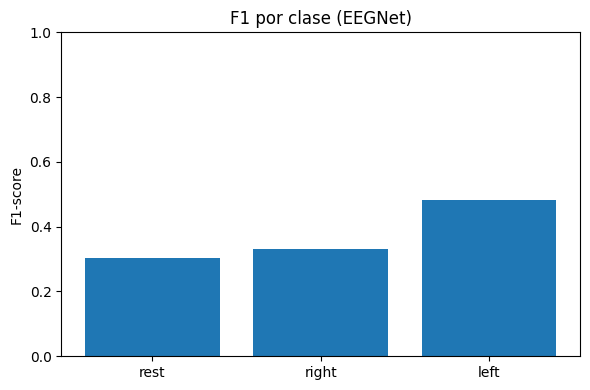

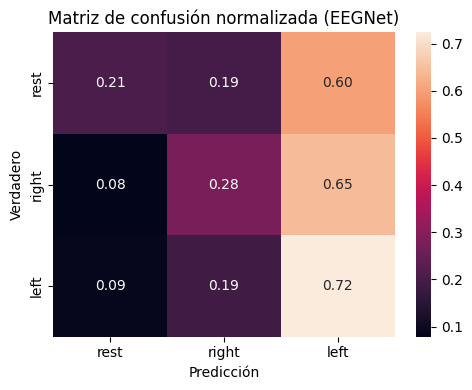

{'y_pred': array([1, 0, 2, ..., 2, 1, 2], shape=(13202,)),
 'cm': array([[ 942,  893, 2747],
        [ 338, 1186, 2771],
        [ 377,  817, 3131]]),
 'cm_norm': array([[0.20558708, 0.19489306, 0.59951986],
        [0.07869616, 0.27613504, 0.6451688 ],
        [0.08716763, 0.18890173, 0.72393064]]),
 'precision': array([0.56849728, 0.40953039, 0.36200717]),
 'recall': array([0.20558708, 0.27613504, 0.72393064]),
 'f1': array([0.30197147, 0.32985677, 0.48265762])}

In [13]:
dl.evaluate(modelo, keras_split, obj.label_map)

In [25]:
#Guardamos el modelo y sus parámetros de normalización
clases = np.unique(pick)
path = f"Movement_clasify/Recursos/models/general/{len(np.unique(obj.sub))}_subjects/{clases}_trained_models_v1"
print(f"Guardando modelo en: {path}")

if not os.path.exists(path):
    os.makedirs(path)

dl.save_model(modelo, mean, std, path = path, name_model = f"Gmodel_{len(obj.X)}_{len(np.unique(obj.sub))}.keras", name_params = f"EEGnet_general_{len(obj.X)}_{len(np.unique(obj.sub))}.npz")


Guardando modelo en: Movement_clasify/Recursos/models/general/97_subjects/[0 1 2 5 6]_trained_models_v1


In [9]:
#Cargar modelo en caso de que ya tenegamos uno guardado
modelo, mean, std = dl.load_model(model_path = "Movement_clasify/Recursos/Modelo_EEG.keras", params_path = "Movement_clasify/Recursos/EEGnet_.npz")

In [18]:
modelo_ft, history_ft, mean, std, keras_split_ft = dl.eeg_fine(modelo, 
                                                        data_fine,
                                                        debug=False, epochs=30)


Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4277 - loss: 1.0560 - val_accuracy: 0.3538 - val_loss: 1.0741
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4504 - loss: 1.0521 - val_accuracy: 0.3385 - val_loss: 1.0737
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4649 - loss: 1.0518 - val_accuracy: 0.3692 - val_loss: 1.0722
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4277 - loss: 1.0518 - val_accuracy: 0.3692 - val_loss: 1.0701
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4649 - loss: 1.0495 - val_accuracy: 0.3846 - val_loss: 1.0687
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4236 - loss: 1.0573 - val_accuracy: 0.3846 - val_loss: 1.0672
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4256 - loss: 1.0544 - val_accuracy: 0.3846 - val_loss: 1.0655
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4112 - loss: 1.0577 - val_accuracy: 0.4000 - val_loss

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000024211015080> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

=== Evaluación EEGNet ===
Clases (índice -> nombre):
  0: rest
  1: right
  2: left

Matriz de confusión (conteos):
[[16 22 24]
 [ 0 15 15]
 [ 0  7 33]]

Reporte de clasificación:
              pre

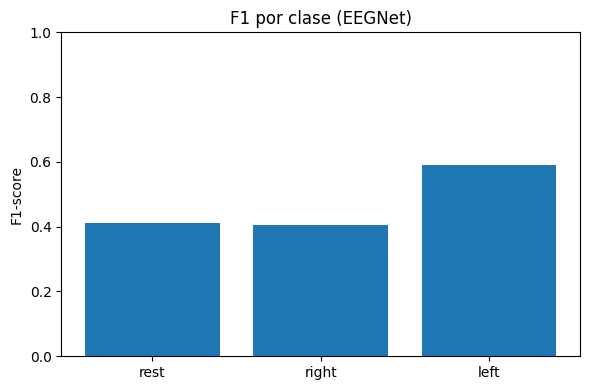

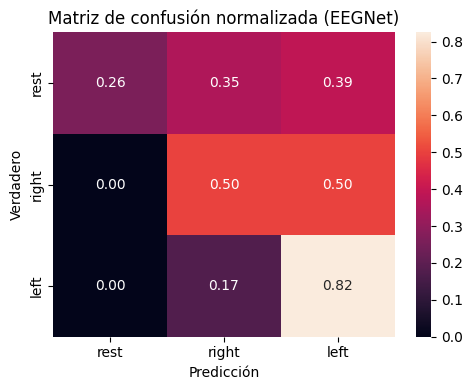

{'y_pred': array([2, 2, 2, 2, 0, 1, 1, 2, 2, 2, 1, 0, 1, 2, 2, 1, 0, 0, 1, 2, 1, 1,
        2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 2, 2, 0, 2, 1, 2, 2, 1, 2, 1, 2, 2,
        1, 1, 2, 2, 2, 1, 1, 0, 2, 2, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 2,
        1, 0, 2, 0, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 2, 1, 0, 2, 2, 1, 2, 2,
        1, 2, 1, 2, 2, 1, 1, 0, 0, 2, 0, 2, 1, 2, 0, 1, 2, 2, 1, 2, 2, 2,
        1, 1, 1, 1, 2, 2, 1, 0, 2, 2, 2, 1, 2, 1, 2, 1, 0, 2, 1, 2, 1, 1]),
 'cm': array([[16, 22, 24],
        [ 0, 15, 15],
        [ 0,  7, 33]]),
 'cm_norm': array([[0.25806452, 0.35483871, 0.38709677],
        [0.        , 0.5       , 0.5       ],
        [0.        , 0.175     , 0.825     ]]),
 'precision': array([1.        , 0.34090909, 0.45833333]),
 'recall': array([0.25806452, 0.5       , 0.825     ]),
 'f1': array([0.41025641, 0.40540541, 0.58928571])}

In [19]:
dl.evaluate(modelo_ft, keras_split_ft, obj.label_map)

In [26]:

path_f = f"Movement_clasify/Recursos/models/fined/{len(np.unique(obj.sub))}_subjects/{clases}_finned_model_v1"
print(f"Guardando modelo en: {path_f}")

if not os.path.exists(path_f):
    os.makedirs(path_f)

dl.save_model(modelo, mean, std, path = path_f, name_model = f"Fmodel_{len(obj.X)}_{len(np.unique(obj.sub))}.keras", name_params = f"EEGnet_fined_{len(obj.X)}_{len(np.unique(obj.sub))}.npz")


Guardando modelo en: Movement_clasify/Recursos/models/fined/97_subjects/[0 1 2 5 6]_finned_model_v1
